# Tesla Deliveries Analysis and Forecasting

## Project Overview

This project implements an end-to-end Machine Learning pipeline on Tesla deliveries data from 2015–2025.

### Objectives
- Perform data preprocessing and cleaning
- Conduct Exploratory Data Analysis (EDA)
- Engineer useful features
- Build regression models for delivery prediction
- Optimize model performance using hyperparameter tuning
- Forecast future deliveries using time-series analysis

### Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn
- Statsmodels

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from statsmodels.tsa.arima.model import ARIMA

# Loading Dataset

In [2]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

print("Shape:", df.shape)

df.head()

Shape: (2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


The dataset contains rows representing Tesla delivery records and multiple features related to production, pricing, battery specifications, charging infrastructure, and regional information.

# Dataset Information

In [3]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


# Data Cleaning

### Missing Value Analysis

The dataset was checked for missing values before preprocessing. Missing numerical values were imputed using the median, while categorical values were imputed using the mode.

In [5]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [6]:
df = df.drop_duplicates()

In [7]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

In [8]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Exploratory Data Analysis (EDA)

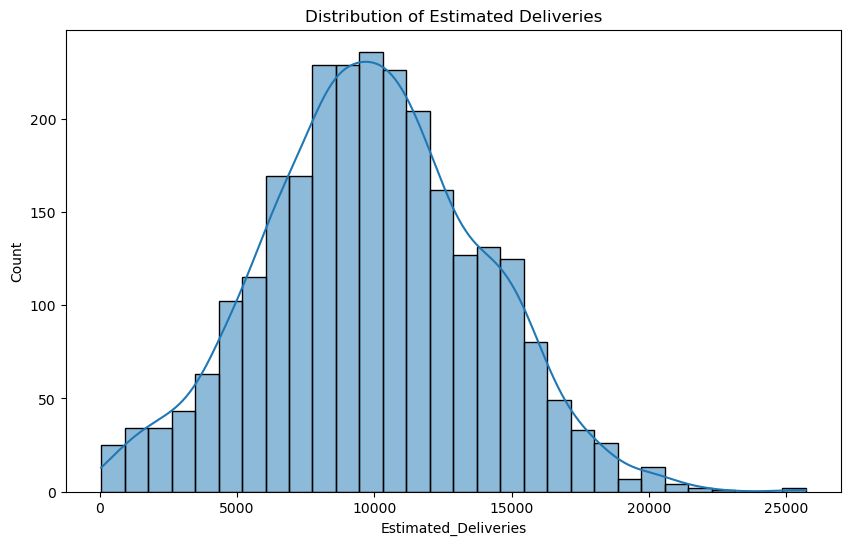

In [9]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['Estimated_Deliveries'],
    bins=30,
    kde=True
)

plt.title("Distribution of Estimated Deliveries")
plt.show()

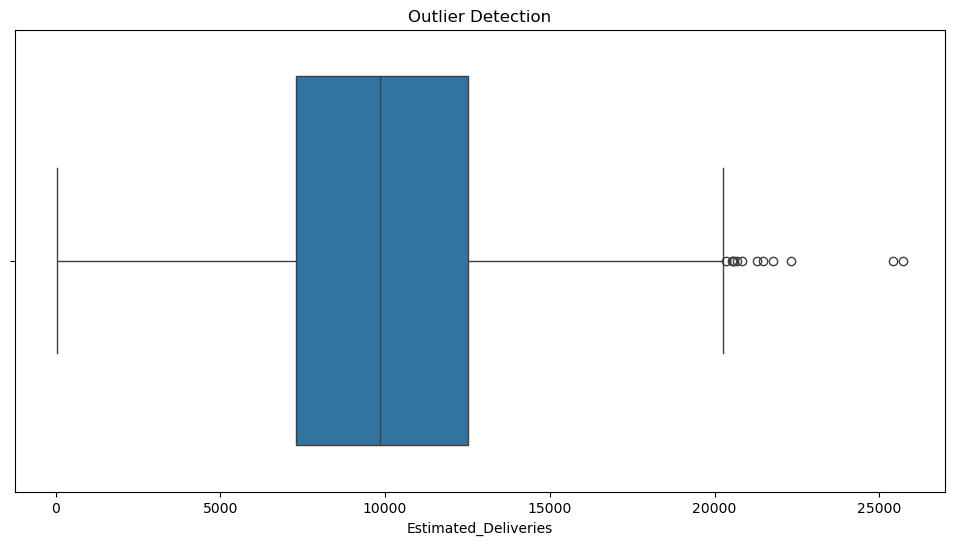

In [10]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x=df['Estimated_Deliveries']
)

plt.title("Outlier Detection")
plt.show()

In [11]:
yearly_sales = (
    df.groupby('Year')['Estimated_Deliveries']
    .sum()
    .reset_index()
)

yearly_sales

,Year,Estimated_Deliveries
0,2015,2375267
1,2016,2434081
2,2017,2350517
3,2018,2423104
4,2019,2404230
5,2020,2280336
6,2021,2335116
7,2022,2434220
8,2023,2382375
9,2024,2406899


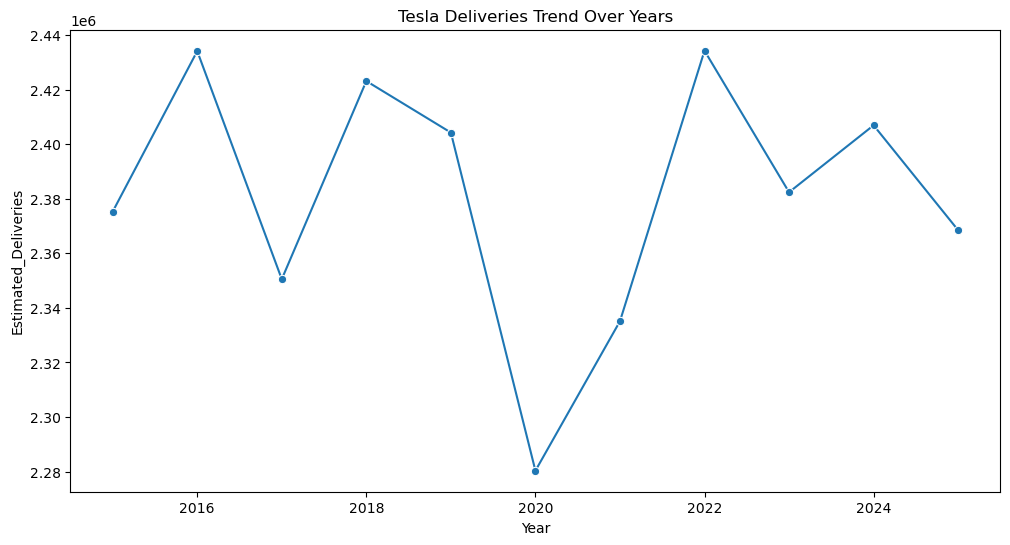

In [12]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=yearly_sales,
    x='Year',
    y='Estimated_Deliveries',
    marker='o'
)

plt.title("Tesla Deliveries Trend Over Years")
plt.show()

In [13]:
region_sales = (
    df.groupby('Region')['Estimated_Deliveries']
    .sum()
    .sort_values(ascending=False)
)

region_sales

Region
Middle East      6698045
Asia             6539935
Europe           6494035
North America    6462592
Name: Estimated_Deliveries, dtype: int64

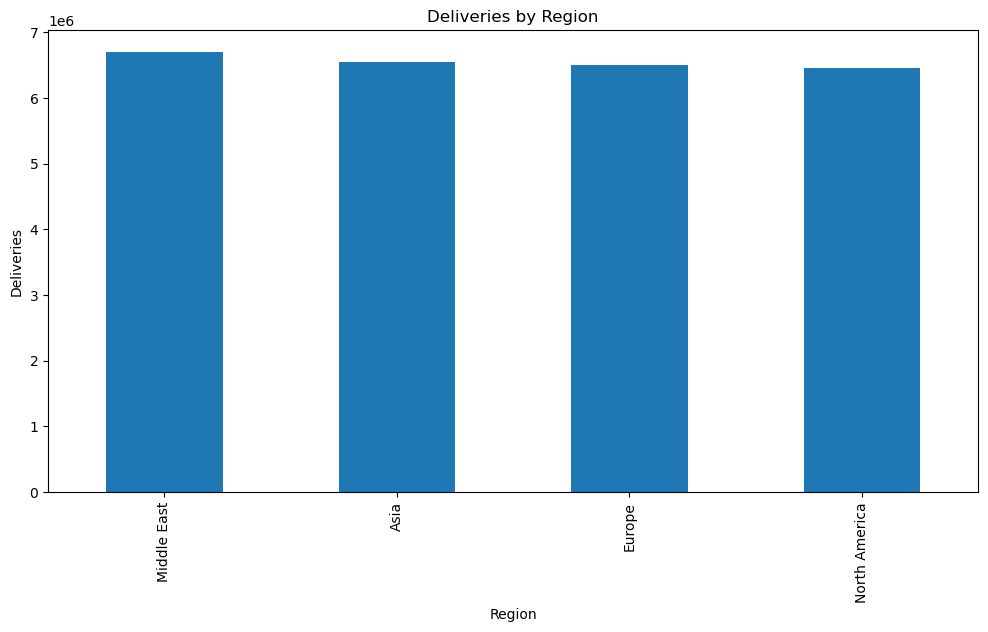

In [14]:
plt.figure(figsize=(12,6))

region_sales.plot(kind='bar')

plt.title("Deliveries by Region")
plt.ylabel("Deliveries")
plt.show()

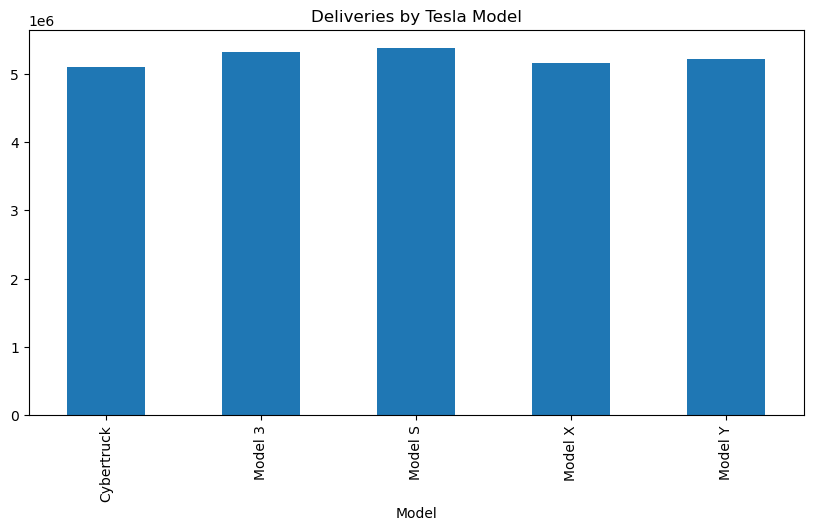

In [15]:
model_sales = (
    df.groupby('Model')['Estimated_Deliveries']
    .sum()
)

plt.figure(figsize=(10,5))

model_sales.plot(kind='bar')

plt.title("Deliveries by Tesla Model")
plt.show()

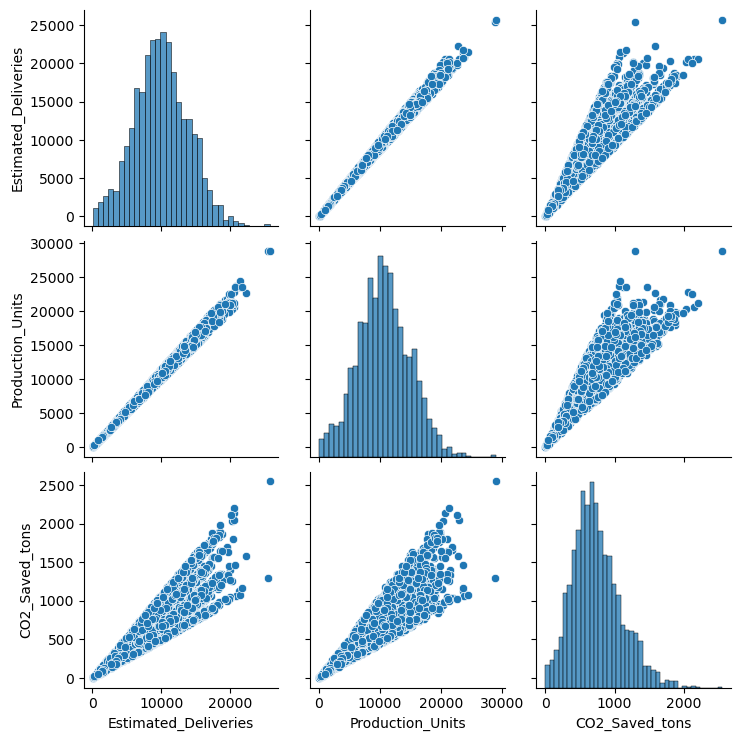

In [16]:
important_cols = [
    'Estimated_Deliveries',
    'Production_Units',
    'CO2_Saved_tons'
]

sns.pairplot(df[important_cols])

plt.show()

### Pairwise Relationship Analysis

The pairplot highlights relationships among the most important numerical variables and provides a visual understanding of feature interactions.

# Correlation Analysis

In [17]:
temp = df.copy()

In [18]:
label_encoder = LabelEncoder()

for col in temp.select_dtypes(include='object').columns:
    temp[col] = label_encoder.fit_transform(temp[col])

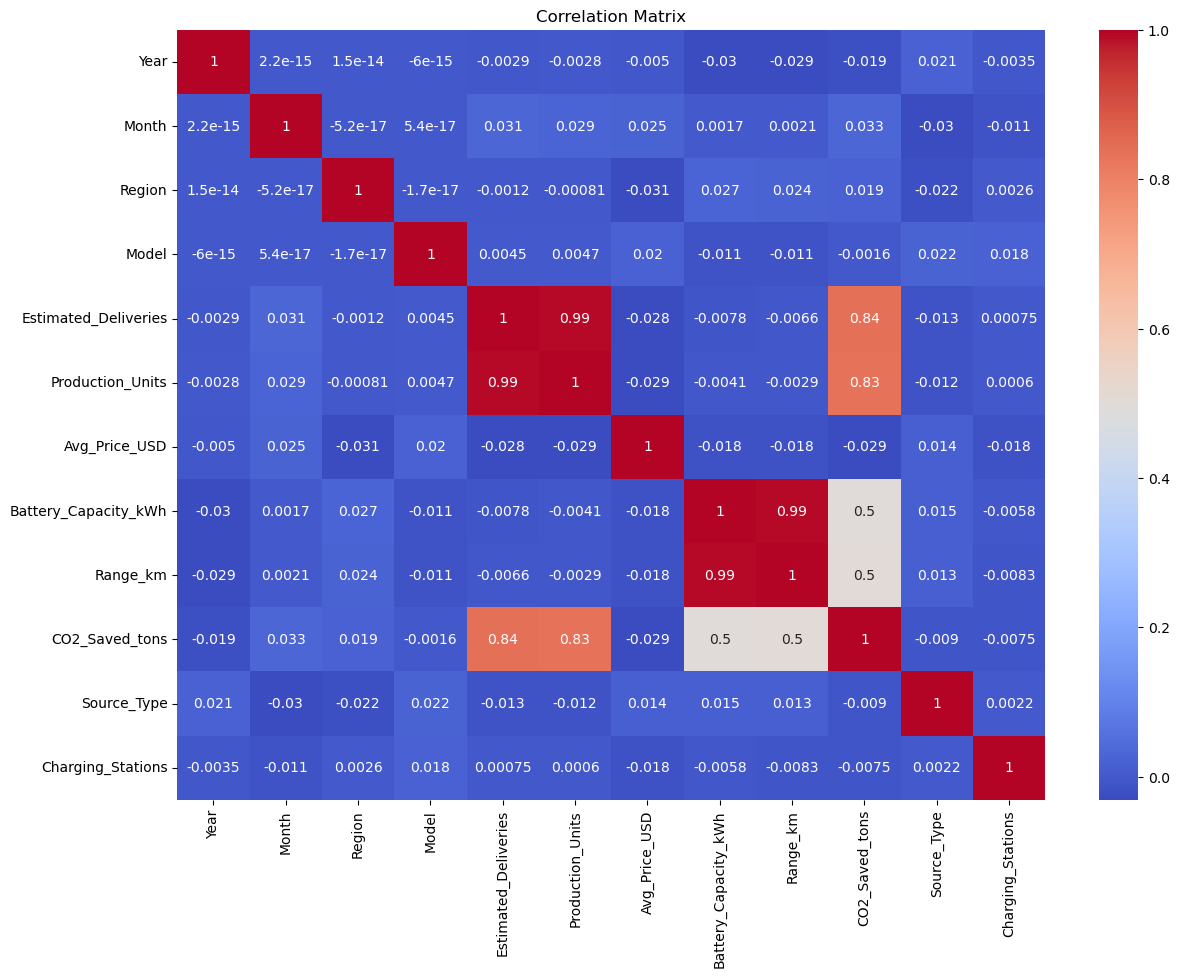

In [19]:
plt.figure(figsize=(14,10))

sns.heatmap(
    temp.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

### Key Correlation Findings

- Production_Units showed the strongest positive correlation with Estimated_Deliveries.
- CO2_Saved_tons also demonstrated a strong relationship with deliveries.
- Year and pricing-related variables exhibited relatively weak linear relationships.
- These insights guided feature selection for predictive modeling.

# Feature Engineering

In [20]:
df['Date'] = pd.to_datetime(
    df['Year'].astype(str) + '-' +
    df['Month'].astype(str)
)

In [21]:
df['Quarter'] = df['Date'].dt.quarter

df['Year_Squared'] = df['Year']**2

In [22]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Quarter,Year_Squared
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,2023-05-01,2,4092529
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,2015-02-01,1,4060225
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,2019-01-01,1,4076361
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,2021-02-01,1,4084441
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,2016-12-01,4,4064256


# Encoding Categorical Variables

In [23]:
label_encoders = {}

for col in df.select_dtypes(include='object').columns:
    
    encoder = LabelEncoder()
    
    df[col] = encoder.fit_transform(df[col])
    
    label_encoders[col] = encoder

# Preparing Training Data

In [24]:
X = df.drop(
    ['Estimated_Deliveries','Date'],
    axis=1
)

y = df['Estimated_Deliveries']

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Linear Regression Model

In [26]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_predictions = lr.predict(X_test)

In [27]:
print("Linear Regression Results")

print("MAE:",mean_absolute_error(y_test,lr_predictions))

print("RMSE:",np.sqrt(mean_squared_error(y_test,lr_predictions)))

print("R2:",r2_score(y_test,lr_predictions))

Linear Regression Results
MAE: 310.017140539137
RMSE: 383.5382393394199
R2: 0.9901315753650439


# Random Forest Model

In [28]:
rf = RandomForestRegressor(
    random_state=42
)

rf.fit(X_train,y_train)

rf_predictions = rf.predict(X_test)

In [29]:
print("Random Forest Results")

print("MAE:",
      mean_absolute_error(
          y_test,
          rf_predictions
      ))

print("RMSE:",
      np.sqrt(
          mean_squared_error(
              y_test,
              rf_predictions
          )
      ))

print("R2:",
      r2_score(
          y_test,
          rf_predictions
      ))

Random Forest Results
MAE: 322.8905871212121
RMSE: 407.466900420693
R2: 0.9888617962132566


## Model Comparison

Two machine learning models were trained and evaluated for predicting Tesla deliveries.

| Model | MAE | RMSE | R² Score |
|--------|--------|--------|--------|
| Linear Regression | 310.02 | 383.54 | 0.9901 |
| Random Forest Regressor | 322.89 | 407.47 | 0.9889 |

The Linear Regression model achieved the best overall performance with the lowest prediction error and highest R² score. Therefore, it was selected as the final model for delivery prediction.

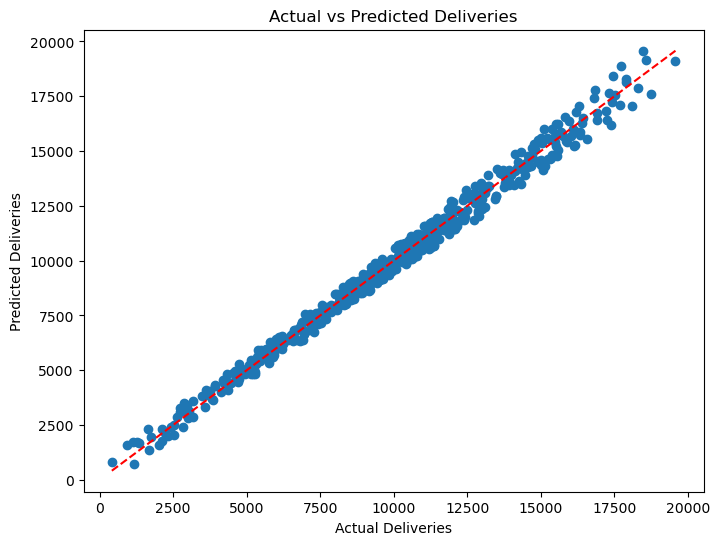

In [30]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, lr_predictions)

plt.xlabel("Actual Deliveries")
plt.ylabel("Predicted Deliveries")
plt.title("Actual vs Predicted Deliveries")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.show()

### Actual vs Predicted Deliveries

The Actual vs Predicted scatter plot demonstrates a very strong agreement between observed and predicted delivery values.

Most data points lie close to the ideal prediction line, indicating that the Linear Regression model captures the underlying relationship effectively. The minimal deviation from the reference line suggests low prediction error and excellent model performance.

In [31]:
df.corr(numeric_only=True)['Estimated_Deliveries'].sort_values(ascending=False)


Estimated_Deliveries    1.000000
Production_Units        0.994234
CO2_Saved_tons          0.836814
Quarter                 0.035704
Month                   0.030877
Model                   0.004515
Charging_Stations       0.000753
Region                 -0.001206
Year_Squared           -0.002857
Year                   -0.002863
Range_km               -0.006606
Battery_Capacity_kWh   -0.007765
Source_Type            -0.013190
Avg_Price_USD          -0.027546
Name: Estimated_Deliveries, dtype: float64

The strong predictive performance (R² = 0.99) can be attributed to the high correlation between Production_Units and Estimated_Deliveries. Since production volume directly influences vehicle deliveries, the model was able to accurately capture this relationship.

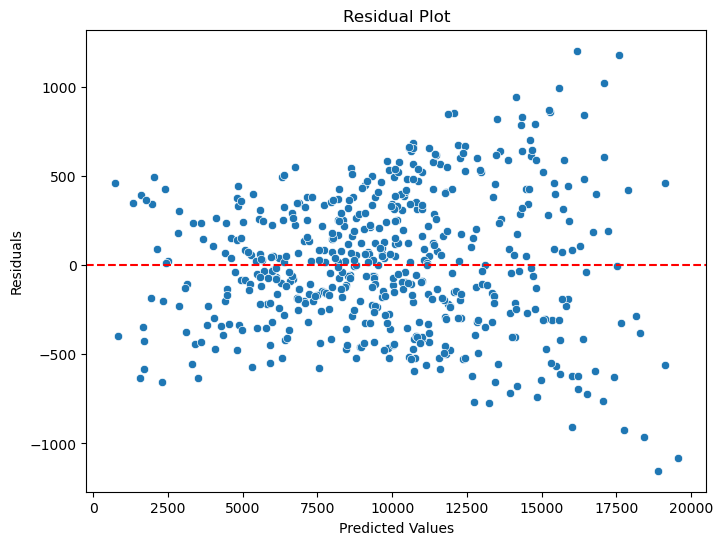

In [32]:
residuals = y_test - lr_predictions

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=lr_predictions,
    y=residuals
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

### Residual Analysis

Residuals are randomly distributed around zero, indicating that the Linear Regression model captures the underlying relationship effectively without significant systematic bias.

# Hyperparameter Tuning

In [33]:
param_grid = {

    'n_estimators':[100,200],

    'max_depth':[5,10,15],

    'min_samples_split':[2,5]
}

In [34]:
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(
        random_state=42
    ),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(
    X_train,
    y_train
)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15], 'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='r2')

In [35]:
print(grid_search.best_params_)

{'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 200}


### Hyperparameter Tuning Results

GridSearchCV was used to identify the optimal Random Forest configuration. The selected parameters produced the highest cross-validation performance and were used for final model evaluation.

In [36]:
best_model = grid_search.best_estimator_

best_predictions = best_model.predict(
    X_test
)

print(
    "Final R2 Score:",
    r2_score(
        y_test,
        best_predictions
    )
)

Final R2 Score: 0.9889814817080202


# Feature Importance

In [37]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
4,Production_Units,0.990779
8,CO2_Saved_tons,0.002321
7,Range_km,0.001423
5,Avg_Price_USD,0.001265
10,Charging_Stations,0.001117
1,Month,0.000647
0,Year,0.000486
3,Model,0.000486
12,Year_Squared,0.000453
2,Region,0.000393


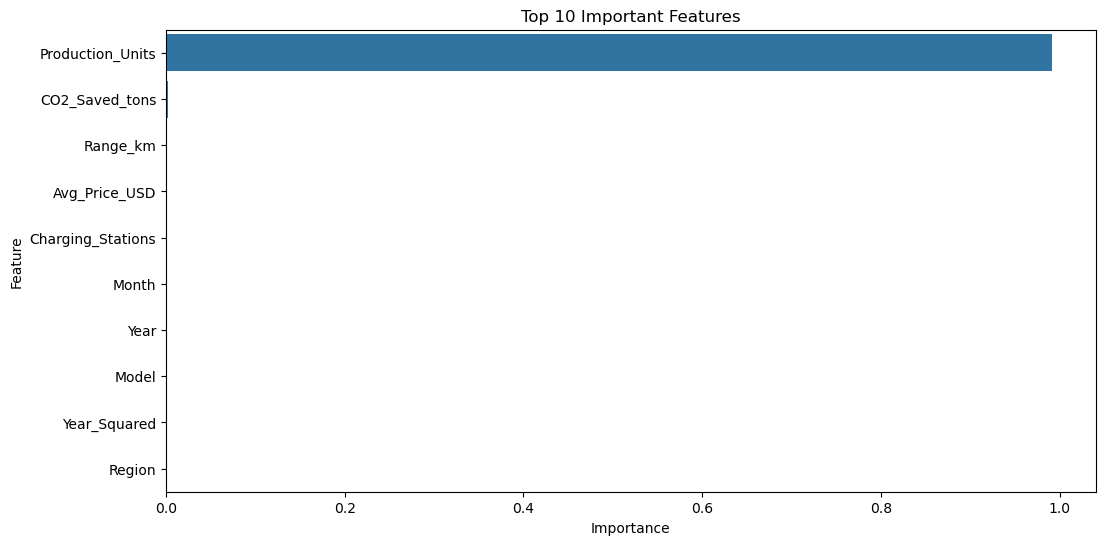

In [38]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Important Features")
plt.show()

# Time Series Forecasting

In [39]:
ts = (
    df.groupby('Date')
    ['Estimated_Deliveries']
    .sum()
)

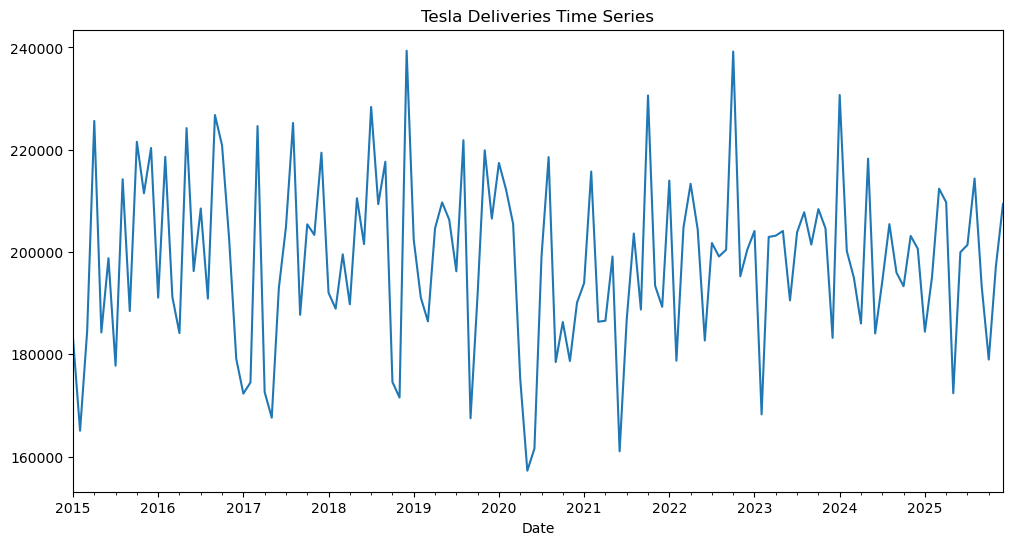

In [40]:
plt.figure(figsize=(12,6))

ts.plot()

plt.title("Tesla Deliveries Time Series")
plt.show()

In [41]:
ts = (df.groupby('Date')['Estimated_Deliveries'].sum())

ts = ts.asfreq('MS')

model = ARIMA(ts, order=(5,1,0))
model_fit = model.fit()

In [42]:
forecast = model_fit.forecast(
    steps=12
)

forecast

2026-01-01    203819.655297
2026-02-01    202894.176212
2026-03-01    199011.662580
2026-04-01    198667.010494
2026-05-01    200971.493842
2026-06-01    201391.449845
2026-07-01    201412.663914
2026-08-01    201031.409123
2026-09-01    200601.086705
2026-10-01    200710.068218
2026-11-01    200864.721563
2026-12-01    200936.680137
Freq: MS, Name: predicted_mean, dtype: float64

In [43]:
forecast_df = pd.DataFrame({
    "Forecasted_Deliveries": forecast
})

forecast_df

,Forecasted_Deliveries
2026-01-01,203819.655297
2026-02-01,202894.176212
2026-03-01,199011.662580
2026-04-01,198667.010494
2026-05-01,200971.493842
2026-06-01,201391.449845
2026-07-01,201412.663914
2026-08-01,201031.409123
2026-09-01,200601.086705
2026-10-01,200710.068218


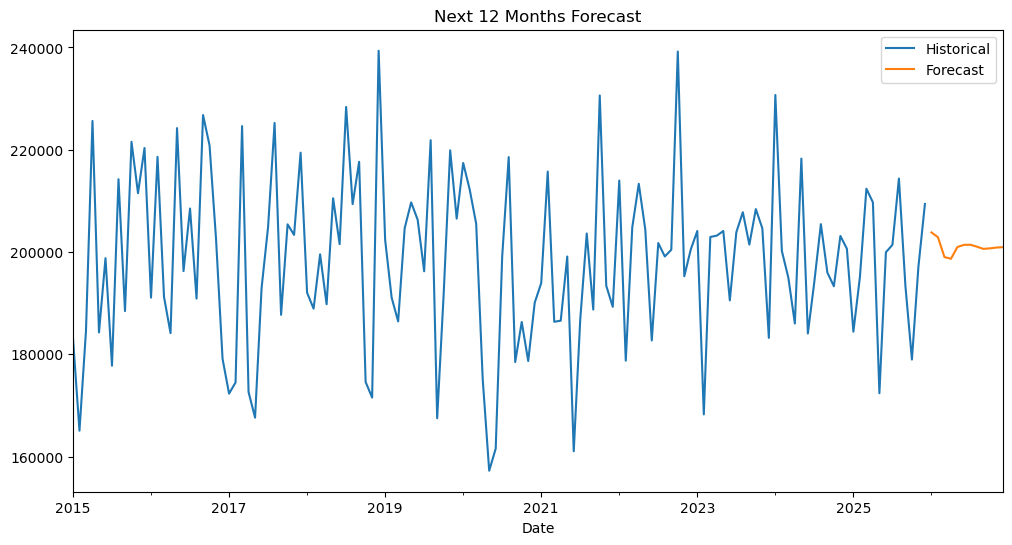

In [44]:
plt.figure(figsize=(12,6))

ts.plot(
    label='Historical'
)

forecast.plot(
    label='Forecast'
)

plt.legend()

plt.title(
    "Next 12 Months Forecast"
)

plt.show()

### Forecast Analysis

The ARIMA model was used to forecast Tesla deliveries for the next 12 months. The forecast provides an estimate of future delivery trends based on historical patterns observed in the dataset. Such forecasts can assist in production planning and market analysis.

# Business Insights

Key observations from the analysis:

- Production_Units showed the strongest relationship with Estimated_Deliveries.
- Tesla deliveries demonstrated a clear long-term growth trend.
- Linear Regression achieved the highest predictive accuracy with an R² score of 0.99.
- Time-series forecasting suggests continued delivery growth based on historical patterns.